#### Assignment 2
**Mahshid Bargahi**

On this notebook we use **Ames Housing dataset**, which contains information about residential homes sold in Ames, Iowa.  
The main goal is to predict **SalePrice** (house sale price).

## Libraries

In [1]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

## Loading dataset

now we have tow final dataset :

- **Selected Features**  :
    - 96 Features retained after Mutual Information (Keeps original interpretable features and higher detail).
    - It's cleaned, encoded and scaled.

In [ ]:
X_train = pd.read_csv(r'D:\sharif\ADS\assignments\assignment2\X_train_scaled_selected.csv')
X_test = pd.read_csv(r'D:\sharif\ADS\assignments\assignment2\X_test_scaled_selected.csv')

y_train = pd.read_csv(r'D:\sharif\ADS\assignments\assignment2\y_train.csv').squeeze()
y_test = pd.read_csv(r'D:\sharif\ADS\assignments\assignment2\y_test.csv').squeeze()

In [3]:
print(X_train.shape)
print(X_test.shape)
X_train.head()

(2283, 96)
(571, 96)


,Quality_Score,Overall Qual,Neighborhood_AvgPrice,Gr Liv Area,Garage Area,Total Bsmt SF,1st Flr SF,Garage Cars,House_Age,Bsmt Qual_num,...,Yr Sold,Exterior 1st_Plywood,BsmtFin SF 2,Exterior 1st_CemntBd,Land Contour_Low,Exter Cond,Neighborhood_CollgCr,Exterior 1st_HdBoard,Exterior 1st_Wd Sdng,Neighborhood_BrDale
0,0.516129,0.444444,201812.568182,-0.646973,0.267475,0.279250,0.327613,0.4,-0.189396,0.8,...,2008,0,-0.296663,0,0,0.75,1,1,0,0
1,0.483871,0.444444,201812.568182,-1.065587,-0.808021,0.313833,0.248440,0.2,0.046625,0.8,...,2006,0,-0.296663,0,0,0.75,1,1,0,0
2,0.548387,0.444444,201812.568182,-1.286235,-0.628772,0.279250,0.206708,0.2,0.046625,0.6,...,2009,0,-0.296663,0,0,0.75,1,1,0,0
3,0.419355,0.333333,122343.444934,-0.925362,-0.897646,0.130899,0.149376,0.2,2.474273,0.4,...,2009,0,-0.296663,0,0,0.50,0,0,0,0
4,0.838710,0.777778,246599.541667,0.594433,1.135420,0.559793,0.562402,0.6,-1.167199,1.0,...,2007,0,-0.296663,0,0,0.75,0,0,0,0


We define a function to evaluate model performance.

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

def evaluate_performance(model_name, y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)
    print(f"{model_name:20} | R² = {r2:.4f} | MAE = ${mae:,.0f} | MAPE = {mape:.2%} | MSE = {mse:,.0f}")
    return {'R2': r2, 'MAE': mae, 'MAPE': mape, 'MSE': mse}


## Linear Regression

Now, we fit our training set to a linear regression model, and then use that model to predict the target values of our test set.

In [6]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_performance = evaluate_performance('Linear Regression', y_test, y_pred_lr)

Linear Regression    | R² = 0.9247 | MAE = $15,619 | MAPE = 10.05% | MSE = 448,484,384


- **R² = 0.9247** → The model explains 92.5% of the variance in SalePrice. This is an excellent fit, indicating that the selected features are highly predictive.
- **MAE = $15,619** → On average, the model's predictions are off by about $15,600. Given that house prices range from ~$50k to ~$700k, this error is quite reasonable.
- **MAPE = 10.05%** → The average percentage error is only 10%, meaning the model's predictions are close to actual values in relative terms.

## Ridge Regression

Ridge regression is a linear model that adds a penalty to the ordinary least squares (OLS) loss function.  
The penalty is the sum of squared coefficients (**L2** norm).

Then the Cost function is defined as :

$\text{Cost} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p w_j^2$



In [7]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

ridge_performance = evaluate_performance("Ridge (alpha=1)", y_test, y_pred_ridge)

Ridge (alpha=1)      | R² = 0.9248 | MAE = $15,545 | MAPE = 9.99% | MSE = 447,969,477


- R² improved only slightly (0.9247 → 0.9248).
- MAE decreased by $74, and MAPE dropped by 0.06%.

## Lasso Regression

Lasso (Least Absolute Shrinkage and Selection Operator) is a linear model that adds a penalty equal to the **sum of absolute values of coefficients** (**L1** norm).

We use alpha = 0.001 (small penalty) to avoid losing too many features.
If many coefficients become zero, it confirms that those features were not useful.

In [8]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1, max_iter=5000)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

lasso_performance = evaluate_performance("Lasso (alpha=0.001)", y_test, y_pred_lasso)

Lasso (alpha=0.001)  | R² = 0.9248 | MAE = $15,592 | MAPE = 10.05% | MSE = 447,958,962


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.167e+11, tolerance: 1.469e+09
  model = cd_fast.enet_coordinate_descent(


We get Warning... Ok, now we find the best alpha and maximum iteration for our model. 

In [9]:
from sklearn.linear_model import Lasso

import warnings
warnings.filterwarnings('ignore')


alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]
iterations = [1000, 2000, 5000, 10000, 20000]


lasso_results = []

for alpha in alphas:
    for max_iter in iterations:
        lasso = Lasso(alpha=alpha, max_iter=max_iter)
        lasso.fit(X_train, y_train)
        y_pred = lasso.predict(X_test)

        lasso_results.append({
            'Alpha': alpha,
            'Max Iter': max_iter,
            'Converged': lasso.n_iter_ < max_iter,  #True -> converged
            'R²': r2_score(y_test, y_pred),
            'MAE': mean_absolute_error(y_test, y_pred),
            'Used Features': np.sum(lasso.coef_ != 0)
        })

lasso_df = pd.DataFrame(lasso_results)

In [10]:
max_iter_needed = lasso_df[lasso_df['Converged'] == True].groupby('Alpha')['Max Iter'].min().max()
print(f"Safe max_iter for all alphas: {max_iter_needed}")

Safe max_iter for all alphas: 10000


Now we choose best alpha that has bigger $R^2$ Score

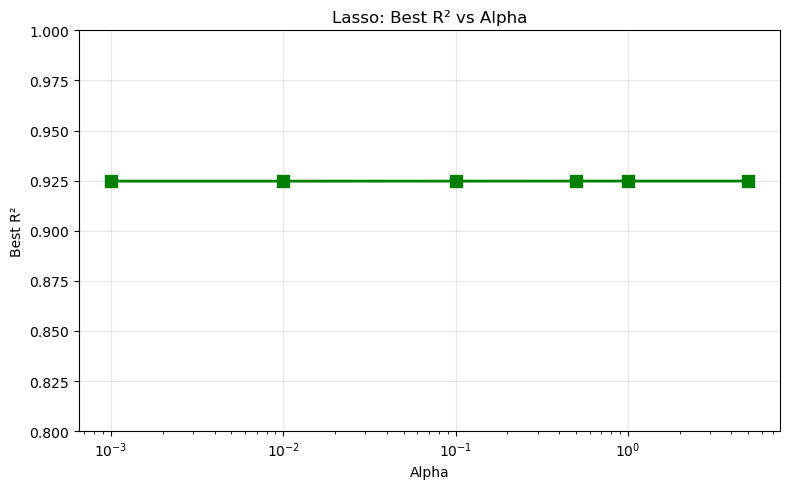

In [41]:
best_per_alpha = lasso_df[lasso_df['Max Iter'] == 10000].groupby('Alpha')['R²'].max().reset_index()

plt.figure(figsize=(8, 5))

# R² vs Alpha
plt.plot(best_per_alpha['Alpha'], best_per_alpha['R²'], 'gs-', linewidth=2, markersize=8)
plt.xscale('log')
plt.ylim(0.80, 1.0)
plt.xlabel('Alpha')
plt.ylabel('Best R²')
plt.title('Lasso: Best R² vs Alpha')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

All alphas produced nearly identical R² (~0.9248).  
 
We choose **alpha = 1.0** because it offers:

- High predictive performance.
- Moderate feature selection without losing too many variables.
- Better interpretability compared to very large alphas.

**Final Lasso model**: alpha = 1.0, max_iter = 10,000

In [43]:
lasso_model = Lasso(alpha=1, max_iter=10000)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

lasso_performance = evaluate_performance("Lasso (alpha=1.0)", y_test, y_pred_lasso)

Lasso (alpha=1.0)    | R² = 0.9248 | MAE = $15,592 | MAPE = 10.04% | MSE = 447,968,118


## Kernel Regression

Kernel Ridge replaces the original features with a **kernel matrix** that measures similarity between every pair of points 
using RBF

- The RBF kernel is defined as:  
K(x, x') = exp(-γ × ||x - x'||²)

- γ (gamma) controls how far a point’s influence reaches.
- ||x - x'||² = squared Euclidean distance.

It then applies Ridge regression in that similarity space.  

This lets the model learn **non‑linear relationships** without explicitly creating high‑degree features, while still benefiting from L2 regularization.


#### Hyperparameter Tuning with GridSearchCV

GridSearchCV is a function from Scikit‑Learn that automatically searches for the **best hyperparameters** of a model.

It tries **every combination** of hyperparameters.

- For each combination:
   - It splits the training data into cv parts (e.g., 5 folds)
   - Trains the model on 4 folds, validates on 1 fold
   - Repeats this 5 times (each fold becomes validation once)
   - Computes the average validation score (R²)

- It chooses the combination with the **highest average cross-validation score**.
- Finally, it trains the best model on the **entire training set** using the best parameters.

In [44]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV

parameter_grid = {
    'alpha' : [0.01, 0.1, 1],
    'gamma' : [0.01, 0.1, 1]
}

kr_model = KernelRidge(kernel='rbf')
grid = GridSearchCV(kr_model, parameter_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

best_kr = grid.best_estimator_

y_pred_kr = best_kr.predict(X_test)

kr_performance = evaluate_performance("Kernel Ridge (RBF)", y_test, y_pred)

Kernel Ridge (RBF)   | R² = 0.9248 | MAE = $15,564 | MAPE = 10.02% | MSE = 447,969,069


## Decision Tree Regression (Optional Model)

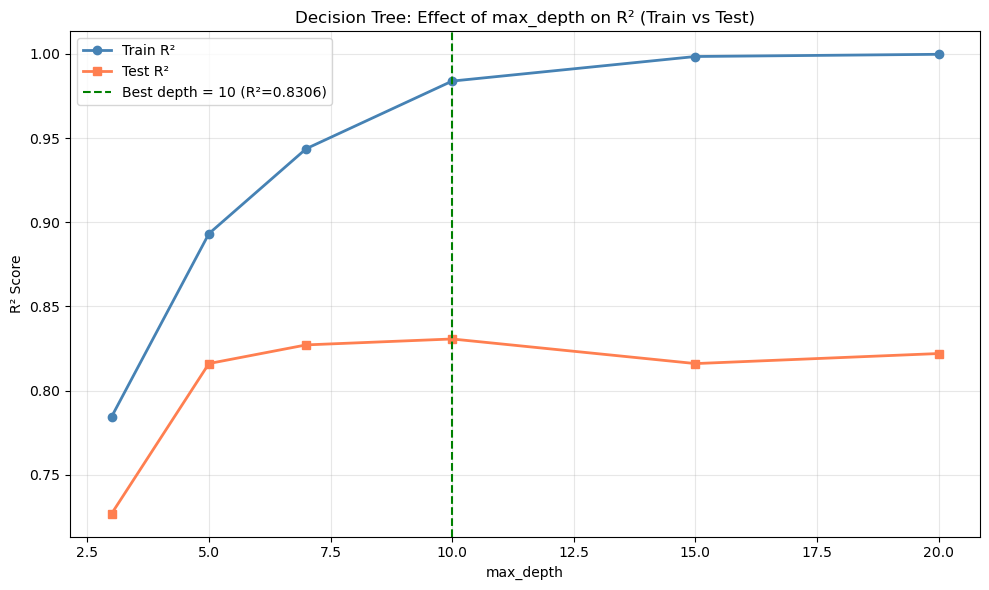

In [59]:
from sklearn.tree import DecisionTreeRegressor

# tuning max_depth
depths = [3, 5, 7, 10, 15, 20, None] 
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_scores.append(r2_score(y_train, y_train_pred))
    test_scores.append(r2_score(y_test, y_test_pred))

best_depth = depths[np.argmax(test_scores)]
best_r2 = max(test_scores)    

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', label='Train R²', color='steelblue', linewidth=2, markersize=6)
plt.plot(depths, test_scores, 's-', label='Test R²', color='coral', linewidth=2, markersize=6)
plt.axvline(best_depth, color='green', linestyle='--', label=f'Best depth = {best_depth} (R²={best_r2:.4f})')
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Decision Tree: Effect of max_depth on R² (Train vs Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


- Best tree depth = 10 with Test R² = 0.8306.
- Deeper depths cause overfitting (Train R² → 1, Test R² drops).
- Shallower depths cause underfitting.

In [60]:
dtree_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dtree_model.fit(X_train, y_train)

y_pred_dt = dtree_model.predict(X_test)

dtree_performance = evaluate_performance("Decision Tree", y_test, y_pred_dt)

Decision Tree        | R² = 0.8306 | MAE = $20,697 | MAPE = 12.63% | MSE = 1,008,583,786


### Let's compare models 

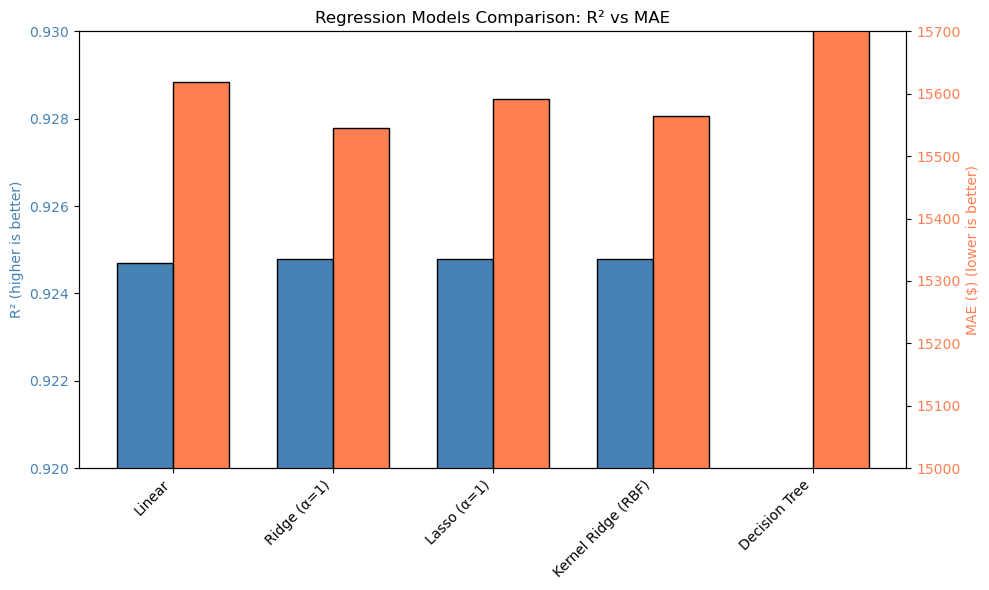

In [63]:
results = {}

results['Linear'] = lr_performance
results['Ridge (α=1)'] = ridge_performance
results['Lasso (α=1)'] = lasso_performance
results['Kernel Ridge (RBF)'] = kr_performance
results['Decision Tree'] = dtree_performance

results_df = pd.DataFrame(results).T

models = results_df.index.tolist()
r2_values = results_df['R2'].values
mae_values = results_df['MAE'].values

x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# R²
bars1 = ax1.bar(x - width/2, r2_values, width, label='R²', color='steelblue', edgecolor='black')
ax1.set_ylabel('R² (higher is better)', color='steelblue')
ax1.set_ylim(0.92, 0.93)
ax1.tick_params(axis='y', labelcolor='steelblue')

# MAE
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, mae_values, width, label='MAE ($)', color='coral', edgecolor='black')
ax2.set_ylabel('MAE ($) (lower is better)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')
ax2.set_ylim(15000, 15700)

ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.set_title('Regression Models Comparison: R² vs MAE')
fig.tight_layout()
plt.show()

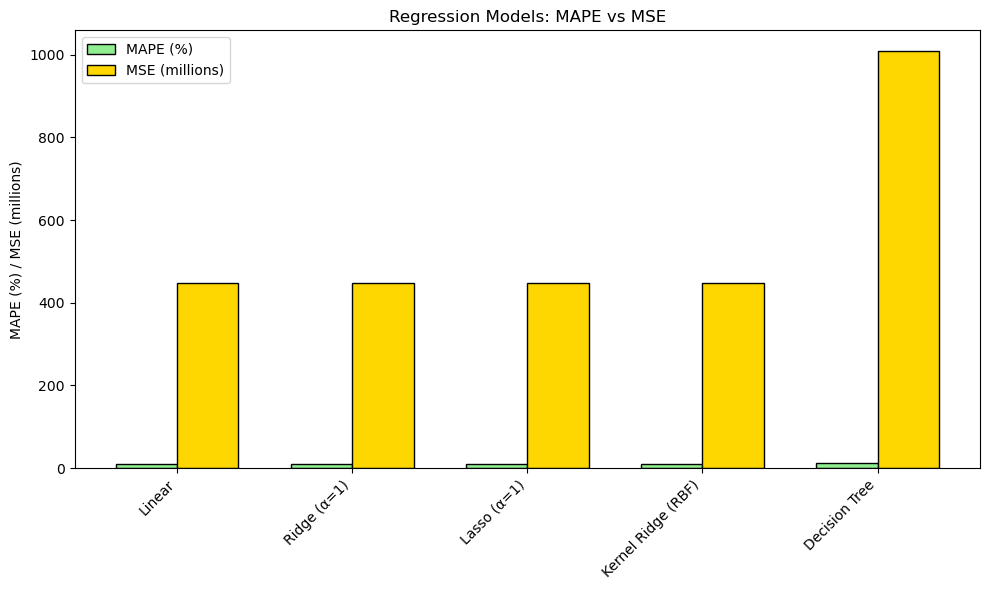

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.35

# MAPE 
bars1 = ax.bar(x - width/2, results_df['MAPE']*100, width, label='MAPE (%)', color='lightgreen', edgecolor='black')
# MSE 
bars2 = ax.bar(x + width/2, results_df['MSE'] / 1e6, width, label='MSE (millions)', color='gold', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('MAPE (%) / MSE (millions)')
ax.set_title('Regression Models: MAPE vs MSE')
ax.legend()
plt.tight_layout()
plt.show()

### Final Comparison

ll four models (Linear, Ridge, Lasso, Kernel Ridge) achieved nearly identical performance:
- R² ≈ 0.9248
- MAE ≈ $15,500–$15,600
- MAPE ≈ 10%

It means that : 

- The selected features already capture most of the predictive information.
- The relationships between features and SalePrice are **almost linear**.
- Adding non‑linearity (Kernel Ridge) or regularization (Ridge, Lasso) did not significantly improve results.

### Which model to choose?
- **Linear Regression** : simplest and most interpretable.
- **Ridge** : slightly more robust (lower MAE, same R²).
- **Lasso** : if feature selection is needed (but here, all features were kept).
- **Kernel Ridge** : not necessary, given the linear nature of the data.
- **Decision Tree** : performed slightly worse than linear models, confirming that the data is **almost linear** and does not require complex non‑linear models.

We proceed with **Ridge (α=1.0)** as the final regression model (best MAE and MAPE).

### **Briefly explain the kernel trick in a few sentences and how it can help achieve better regression results.**


The kernel trick is a mathematical technique that allows a linear model to learn **non‑linear relationships** without explicitly transforming the data into a higher‑dimensional space using a similarity function (kernel).
 
This improves regression when the relationship between features and target is not a straight line.




